---
# Experiment 2: Email Spam/Ham Classification using Naïve Bayes and KNN

**Aim:** To build and compare spam classifiers using Naïve Bayes (Gaussian, Multinomial, Bernoulli) and K-Nearest Neighbours (KNN), evaluate their performance using standard metrics, and analyse computational complexity.

**Dataset:** Spambase Dataset — 4601 emails, 57 numerical features, binary label (0 = Ham, 1 = Spam).

**Theory:**
- **Naïve Bayes** is a probabilistic classifier based on Bayes' theorem: P(C|X) = P(X|C)·P(C) / P(X). It assumes features are conditionally independent given the class.
- **KNN** is a lazy learner that classifies a sample by majority vote among its k nearest neighbours using a distance metric.


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline

print('All Experiment 2 libraries imported successfully!')


All Experiment 2 libraries imported successfully!


## Step 2: Load Spambase Dataset

The Spambase dataset has 57 continuous features derived from email content (word frequencies, character frequencies, run-length attributes) and a binary label (1 = spam, 0 = ham).

In [2]:
# Load spambase dataset (same file used in Experiment 1 EDA)
col_names = [f'feature_{i}' for i in range(57)] + ['label']
df_spam = pd.read_csv('spambase.data', header=None, names=col_names)

print('Shape:', df_spam.shape)
print('\nFirst 5 rows:')
print(df_spam.head())
print('\nClass Distribution (0=Ham, 1=Spam):')
print(df_spam['label'].value_counts())
print('\nMissing Values:', df_spam.isnull().sum().sum())
print('\nSummary Statistics:')
print(df_spam.describe())


Shape: (4601, 58)

First 5 rows:
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0       0.00       0.64       0.64        0.0       0.32       0.00   
1       0.21       0.28       0.50        0.0       0.14       0.28   
2       0.06       0.00       0.71        0.0       1.23       0.19   
3       0.00       0.00       0.00        0.0       0.63       0.00   
4       0.00       0.00       0.00        0.0       0.63       0.00   

   feature_6  feature_7  feature_8  feature_9  ...  feature_48  feature_49  \
0       0.00       0.00       0.00       0.00  ...        0.00       0.000   
1       0.21       0.07       0.00       0.94  ...        0.00       0.132   
2       0.19       0.12       0.64       0.25  ...        0.01       0.143   
3       0.31       0.63       0.31       0.63  ...        0.00       0.137   
4       0.31       0.63       0.31       0.63  ...        0.00       0.135   

   feature_50  feature_51  feature_52  feature_53  feature_54  feature_

## Step 3: Preprocessing

- No missing values in Spambase, so no imputation needed.
- **Normalization (MinMaxScaler)** is applied for KNN and Bernoulli NB (since KNN is distance-based and sensitive to feature scale).
- **Standardization (StandardScaler)** is applied for Gaussian NB.
- Raw non-negative features are used for Multinomial NB (it requires non-negative counts).


In [3]:
X = df_spam.drop('label', axis=1).values
y = df_spam['label'].values

# Train-test split (80-20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler - for Gaussian NB and KNN
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train_raw)
X_test_std  = scaler_std.transform(X_test_raw)

# MinMaxScaler - for Multinomial NB (needs non-negative) and Bernoulli NB
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train_raw)
X_test_mm  = scaler_mm.transform(X_test_raw)

print(f'Training set size : {X_train_raw.shape}')
print(f'Test set size     : {X_test_raw.shape}')
print(f'Class balance (train) - Ham: {(y_train==0).sum()}, Spam: {(y_train==1).sum()}')


Training set size : (3680, 57)
Test set size     : (921, 57)
Class balance (train) - Ham: 2230, Spam: 1450


## Step 4: Exploratory Data Analysis (EDA)

> **Note:** Detailed EDA for the Spambase dataset was performed in Experiment 1. Here we show the key plots relevant to model selection.


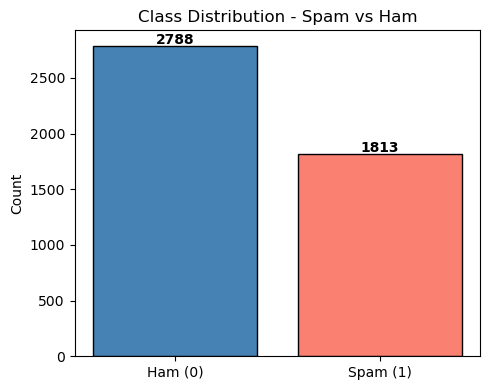

Interpretation: Dataset is slightly imbalanced — 60% Ham, 40% Spam. Stratified split ensures both sets reflect this ratio.


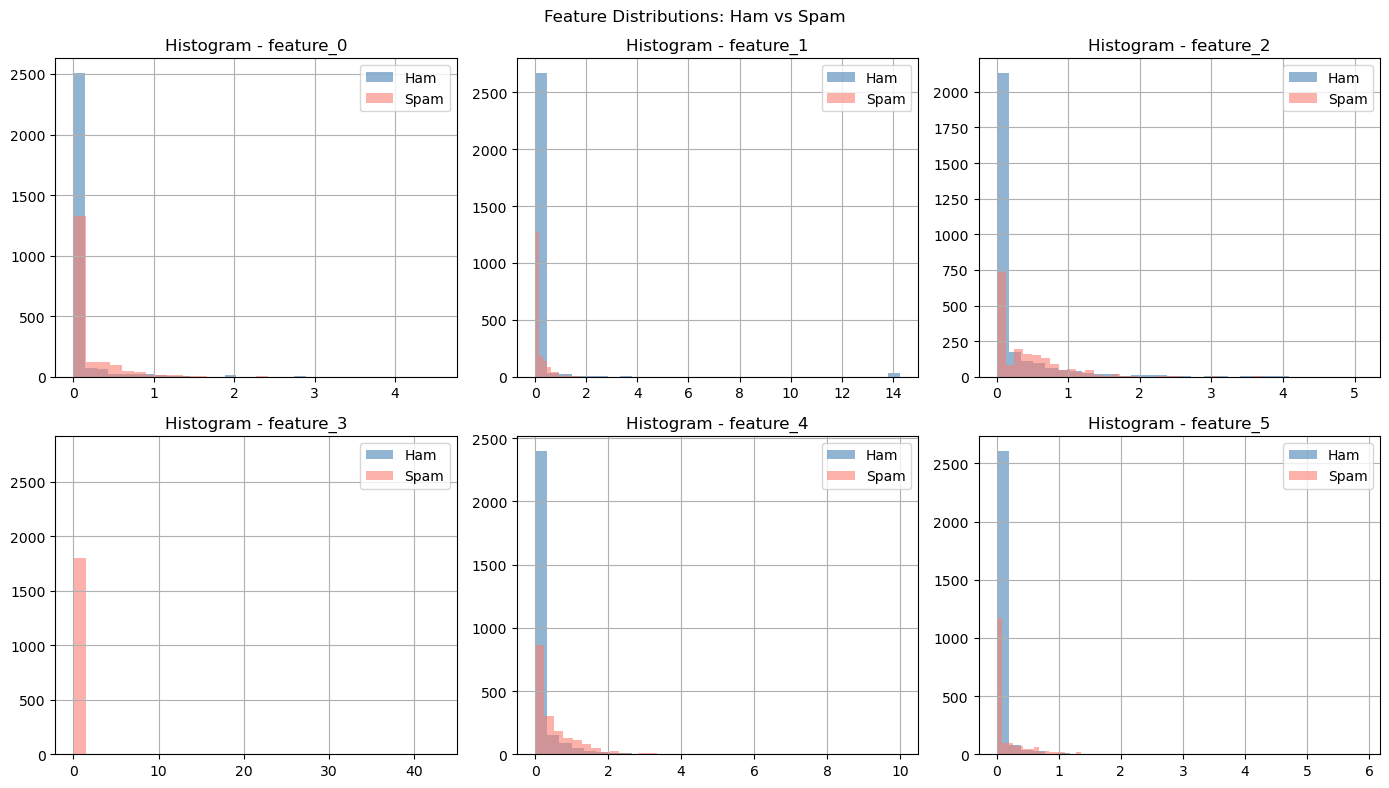

Interpretation: Most features are right-skewed and sparse. Spam emails tend to have higher word frequency values for certain features, suggesting discriminative power.


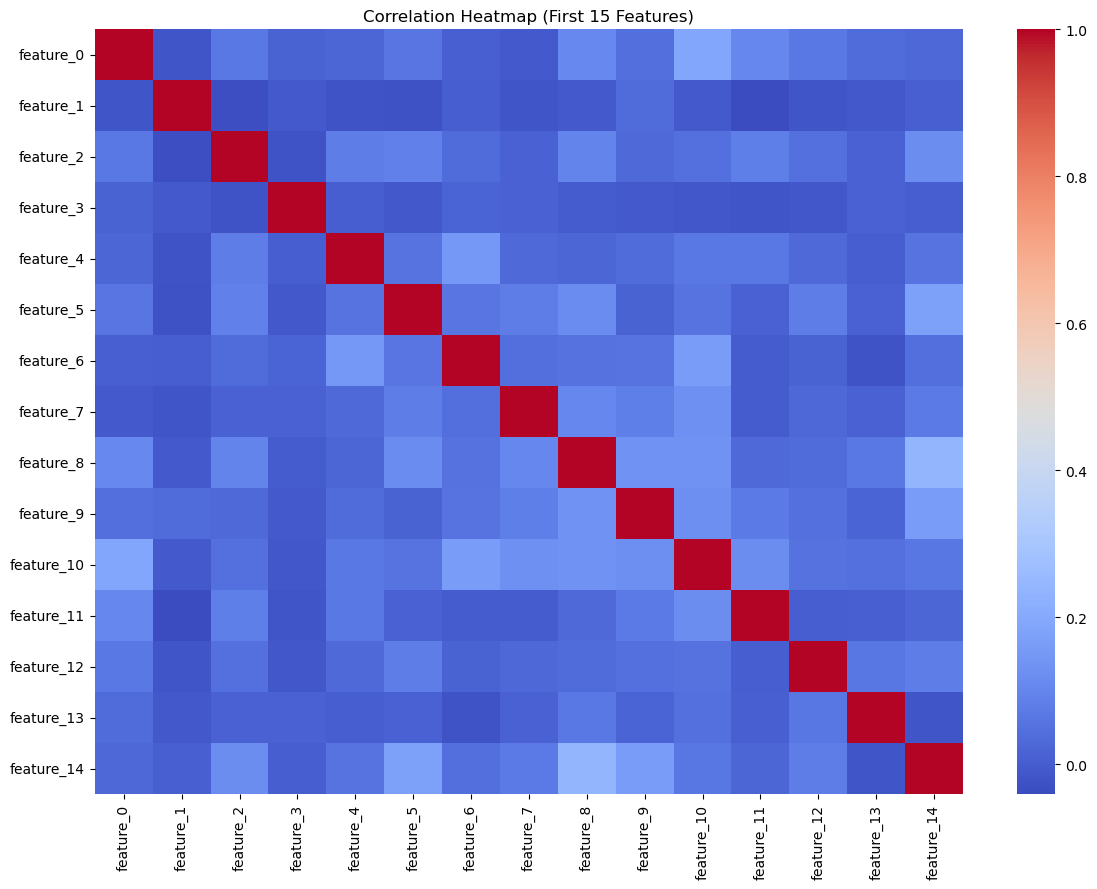

Interpretation: Most features have low inter-correlation, supporting the Naïve Bayes conditional independence assumption.


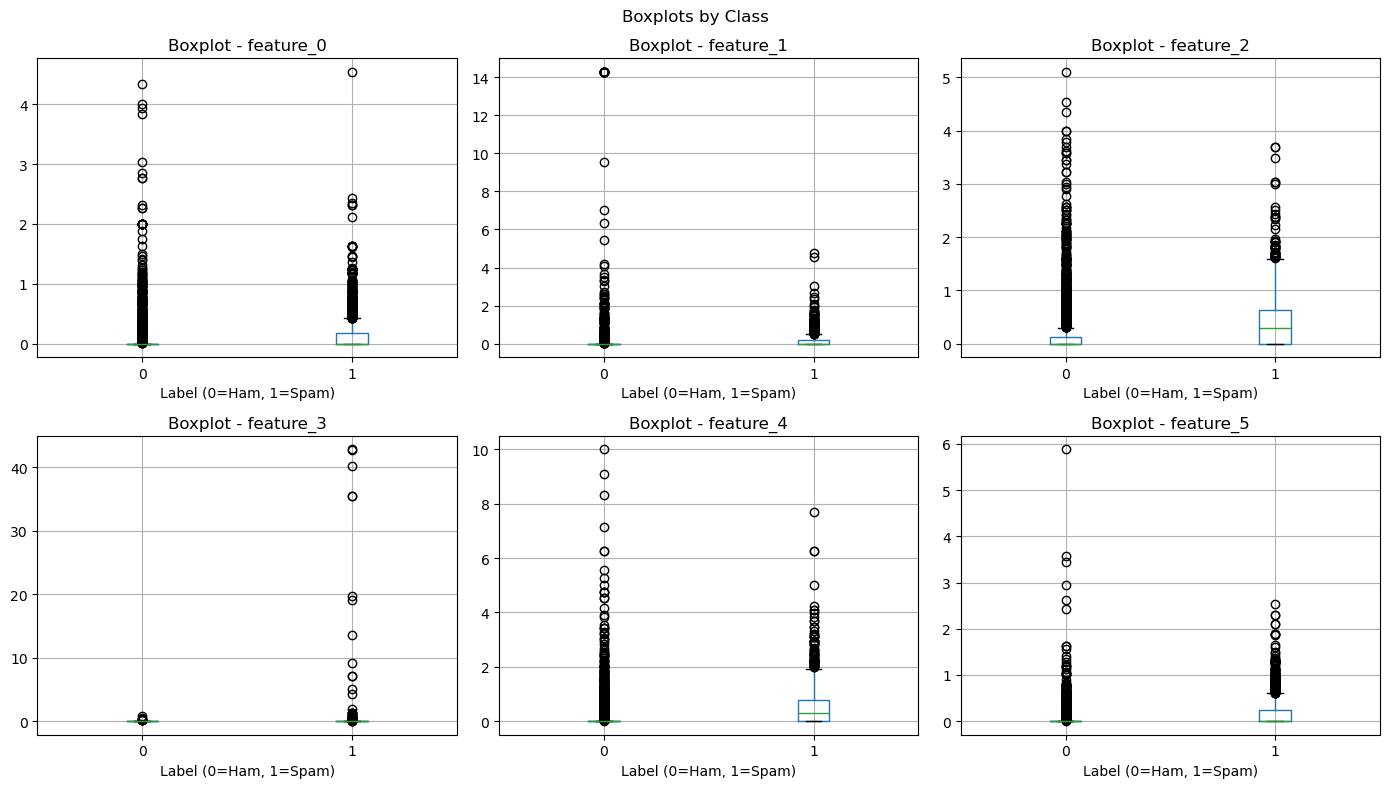

Interpretation: Spam emails consistently show higher medians and more outliers for word-frequency features, confirming they are informative for classification.


In [4]:
# 1. Class Distribution
plt.figure(figsize=(5,4))
labels = ['Ham (0)', 'Spam (1)']
counts = df_spam['label'].value_counts().sort_index()
plt.bar(labels, counts.values, color=['steelblue','salmon'], edgecolor='black')
plt.title('Class Distribution - Spam vs Ham')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v+20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('Interpretation: Dataset is slightly imbalanced — 60% Ham, 40% Spam. Stratified split ensures both sets reflect this ratio.')

# 2. Histograms of top 6 features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
top_features = [f'feature_{i}' for i in range(6)]
for i, col in enumerate(top_features):
    ax = axes[i//3, i%3]
    df_spam[df_spam['label']==0][col].hist(bins=30, ax=ax, alpha=0.6, color='steelblue', label='Ham')
    df_spam[df_spam['label']==1][col].hist(bins=30, ax=ax, alpha=0.6, color='salmon', label='Spam')
    ax.set_title(f'Histogram - {col}')
    ax.legend()
plt.suptitle('Feature Distributions: Ham vs Spam')
plt.tight_layout()
plt.show()
print('Interpretation: Most features are right-skewed and sparse. Spam emails tend to have higher word frequency values for certain features, suggesting discriminative power.')

# 3. Correlation Heatmap (first 15 features)
plt.figure(figsize=(12,9))
sns.heatmap(df_spam[[f'feature_{i}' for i in range(15)]].corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (First 15 Features)')
plt.tight_layout()
plt.show()
print('Interpretation: Most features have low inter-correlation, supporting the Naïve Bayes conditional independence assumption.')

# 4. Box plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(top_features):
    ax = axes[i//3, i%3]
    df_spam.boxplot(column=col, by='label', ax=ax)
    ax.set_title(f'Boxplot - {col}')
    ax.set_xlabel('Label (0=Ham, 1=Spam)')
plt.suptitle('Boxplots by Class')
plt.tight_layout()
plt.show()
print('Interpretation: Spam emails consistently show higher medians and more outliers for word-frequency features, confirming they are informative for classification.')


## Step 5: Naïve Bayes Classifiers

| Variant | Assumption | Best for |
|---|---|---|
| **Gaussian NB** | Features follow a normal distribution | Continuous features |
| **Multinomial NB** | Features are counts or frequencies | Text classification |
| **Bernoulli NB** | Features are binary (0/1) | Binary word presence |


In [5]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1'       : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4)
    }
    return metrics, y_pred, y_prob

nb_results = {}
nb_times   = {}
nb_preds   = {}
nb_probs   = {}

# --- Gaussian NB (standardized features) ---
gnb = GaussianNB()
t0 = time.time(); gnb.fit(X_train_std, y_train); nb_times['Gaussian'] = {'train': round(time.time()-t0,4)}
t0 = time.time(); metrics, preds, probs = evaluate_model(gnb, X_test_std, y_test, 'Gaussian NB'); nb_times['Gaussian']['predict'] = round(time.time()-t0,4)
nb_results['Gaussian'] = metrics; nb_preds['Gaussian'] = preds; nb_probs['Gaussian'] = probs

# --- Multinomial NB (min-max scaled, non-negative) ---
mnb = MultinomialNB()
t0 = time.time(); mnb.fit(X_train_mm, y_train); nb_times['Multinomial'] = {'train': round(time.time()-t0,4)}
t0 = time.time(); metrics, preds, probs = evaluate_model(mnb, X_test_mm, y_test, 'Multinomial NB'); nb_times['Multinomial']['predict'] = round(time.time()-t0,4)
nb_results['Multinomial'] = metrics; nb_preds['Multinomial'] = preds; nb_probs['Multinomial'] = probs

# --- Bernoulli NB (min-max scaled) ---
bnb = BernoulliNB()
t0 = time.time(); bnb.fit(X_train_mm, y_train); nb_times['Bernoulli'] = {'train': round(time.time()-t0,4)}
t0 = time.time(); metrics, preds, probs = evaluate_model(bnb, X_test_mm, y_test, 'Bernoulli NB'); nb_times['Bernoulli']['predict'] = round(time.time()-t0,4)
nb_results['Bernoulli'] = metrics; nb_preds['Bernoulli'] = preds; nb_probs['Bernoulli'] = probs

# --- Print Comparison Table ---
nb_df = pd.DataFrame(nb_results, index=['Accuracy','Precision','Recall','F1','ROC-AUC'])
print('='*55)
print('        Naïve Bayes Comparison Table')
print('='*55)
print(nb_df.to_string())
print('\nInterpretation: Gaussian NB generally performs best on continuous features. Bernoulli NB treats each feature as binary presence/absence. Multinomial NB works well with count-like frequencies.')


        Naïve Bayes Comparison Table
           Gaussian  Multinomial  Bernoulli
Accuracy     0.8328       0.8958     0.8795
Precision    0.7146       0.9349     0.8684
Recall       0.9587       0.7906     0.8182
F1           0.8188       0.8567     0.8426
ROC-AUC      0.9376       0.9612     0.9457

Interpretation: Gaussian NB generally performs best on continuous features. Bernoulli NB treats each feature as binary presence/absence. Multinomial NB works well with count-like frequencies.


### Naïve Bayes — Confusion Matrices and ROC Curves

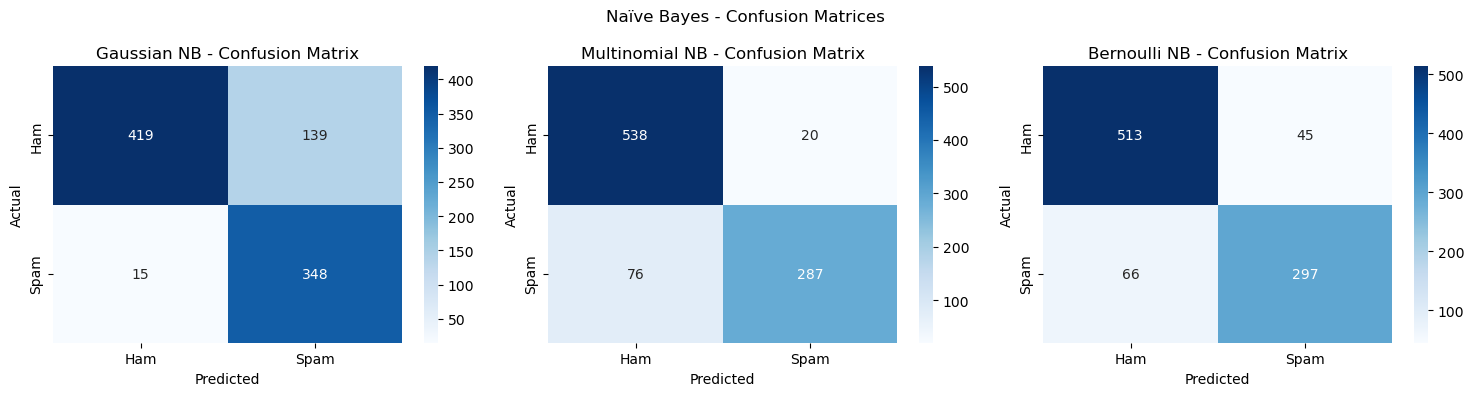

Interpretation: The confusion matrix shows True Positives (Spam correctly identified), False Negatives (Spam missed), and False Positives (Ham wrongly flagged as Spam). False Negatives are costly in spam filtering.


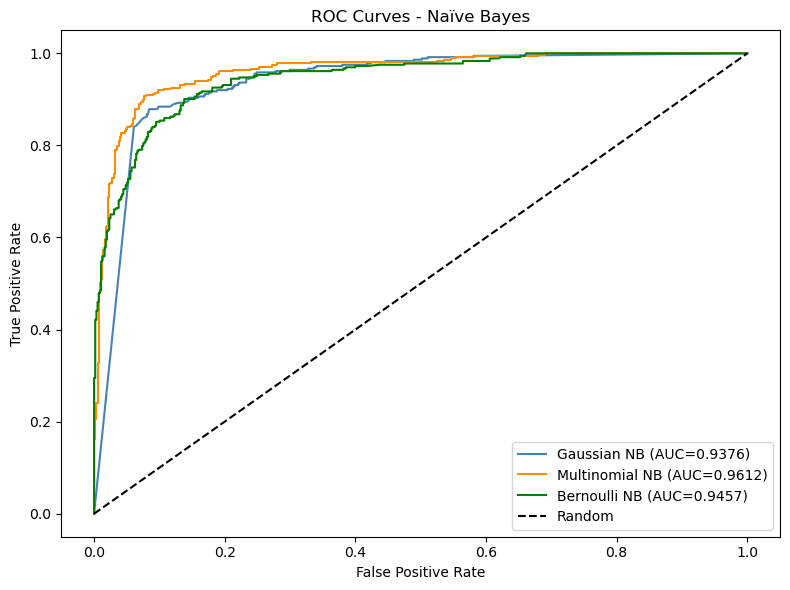

Interpretation: Higher AUC (closer to 1.0) indicates better discrimination between Ham and Spam. The model above the diagonal line is better than random guessing.


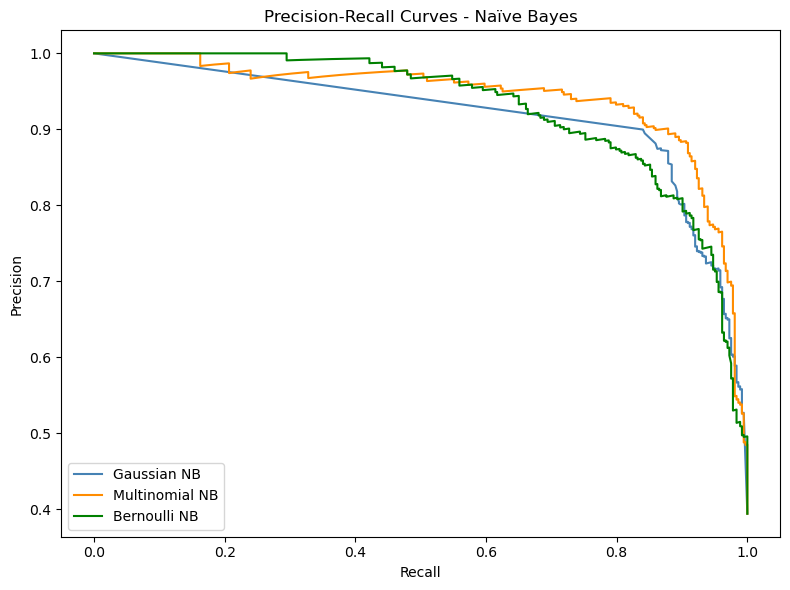

Interpretation: PR curves are more informative than ROC when classes are imbalanced. A curve closer to the top-right corner indicates a better model.


In [6]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
nb_names = ['Gaussian', 'Multinomial', 'Bernoulli']
for ax, name in zip(axes, nb_names):
    cm = confusion_matrix(y_test, nb_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(f'{name} NB - Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Naïve Bayes - Confusion Matrices')
plt.tight_layout()
plt.show()
print('Interpretation: The confusion matrix shows True Positives (Spam correctly identified), False Negatives (Spam missed), and False Positives (Ham wrongly flagged as Spam). False Negatives are costly in spam filtering.')

# ROC Curves
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'green']
for name, color in zip(nb_names, colors):
    fpr, tpr, _ = roc_curve(y_test, nb_probs[name])
    auc = nb_results[name]['ROC-AUC']
    plt.plot(fpr, tpr, color=color, label=f'{name} NB (AUC={auc})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Naïve Bayes')
plt.legend(); plt.tight_layout(); plt.show()
print('Interpretation: Higher AUC (closer to 1.0) indicates better discrimination between Ham and Spam. The model above the diagonal line is better than random guessing.')

# Precision-Recall Curves
plt.figure(figsize=(8, 6))
for name, color in zip(nb_names, colors):
    prec, rec, _ = precision_recall_curve(y_test, nb_probs[name])
    plt.plot(rec, prec, color=color, label=f'{name} NB')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Naïve Bayes')
plt.legend(); plt.tight_layout(); plt.show()
print('Interpretation: PR curves are more informative than ROC when classes are imbalanced. A curve closer to the top-right corner indicates a better model.')


## Step 6: KNN — Effect of k

KNN classifies a new point by looking at its k nearest neighbours and choosing the majority class. A small k can overfit; a large k can underfit.

              KNN Comparison Table (varying k)
    Accuracy  Precision  Recall      F1  ROC-AUC
k                                               
1     0.8990     0.8792  0.8623  0.8707   0.8926
3     0.8979     0.8726  0.8678  0.8702   0.9360
5     0.9077     0.8861  0.8788  0.8824   0.9506
7     0.9088     0.8930  0.8733  0.8830   0.9566
9     0.9088     0.8930  0.8733  0.8830   0.9602
11    0.9099     0.9000  0.8678  0.8836   0.9622


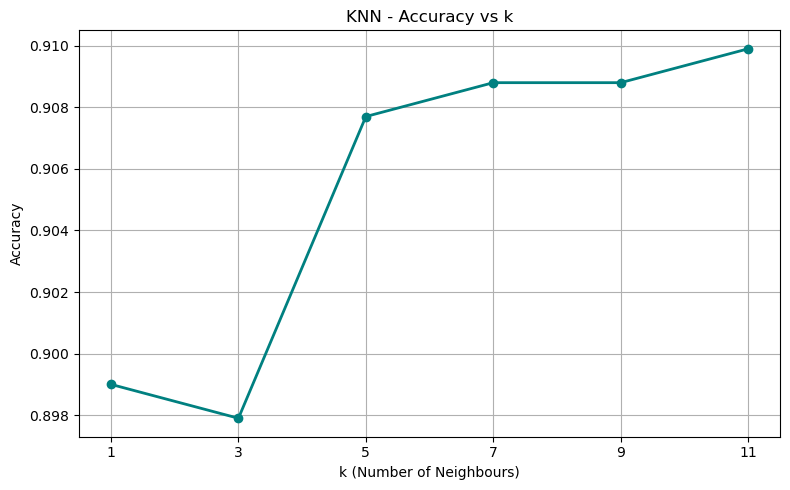


Optimal k = 11 with Accuracy = 0.9099
Interpretation: k=1 tends to overfit (memorises training data). As k increases the boundary smooths out. The optimal k balances bias and variance.


In [7]:
k_values = [1, 3, 5, 7, 9, 11]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    metrics, preds, probs = evaluate_model(knn, X_test_std, y_test, f'KNN k={k}')
    knn_results[k] = metrics

knn_df = pd.DataFrame(knn_results, index=['Accuracy','Precision','Recall','F1','ROC-AUC']).T
knn_df.index.name = 'k'
print('='*65)
print('              KNN Comparison Table (varying k)')
print('='*65)
print(knn_df.to_string())

# Accuracy vs k plot
plt.figure(figsize=(8,5))
plt.plot(k_values, knn_df['Accuracy'], marker='o', color='teal', linewidth=2)
plt.title('KNN - Accuracy vs k')
plt.xlabel('k (Number of Neighbours)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = knn_df['Accuracy'].idxmax()
print(f'\nOptimal k = {best_k} with Accuracy = {knn_df.loc[best_k, "Accuracy"]}')
print('Interpretation: k=1 tends to overfit (memorises training data). As k increases the boundary smooths out. The optimal k balances bias and variance.')


## Step 7: KDTree vs BallTree

| Algorithm | Structure | Best for |
|---|---|---|
| **KDTree** | Binary space partitioning | Low-dimensional data (< ~20 features) |
| **BallTree** | Hypersphere partitioning | High-dimensional or non-Euclidean data |


In [8]:
tree_results = {}

for algo in ['kd_tree', 'ball_tree']:
    knn_tree = KNeighborsClassifier(n_neighbors=best_k, algorithm=algo)
    t0 = time.time(); knn_tree.fit(X_train_std, y_train); train_t = round(time.time()-t0, 4)
    t0 = time.time(); y_pred = knn_tree.predict(X_test_std); pred_t = round(time.time()-t0, 4)
    acc = round(accuracy_score(y_test, y_pred), 4)
    tree_results[algo] = {'Accuracy': acc, 'Training Time (s)': train_t, 'Prediction Time (s)': pred_t}

tree_df = pd.DataFrame(tree_results).T
tree_df.index = ['KDTree', 'BallTree']
print('='*50)
print('      KDTree vs BallTree Comparison')
print('='*50)
print(tree_df.to_string())
print('\nInterpretation: Both structures give similar accuracy. KDTree is faster for low-dimensional data. BallTree is preferable for high-dimensional data (like the 57-feature Spambase). Brute force is fastest for very small datasets.')


      KDTree vs BallTree Comparison
          Accuracy  Training Time (s)  Prediction Time (s)
KDTree      0.9099             0.0338               0.0989
BallTree    0.9099             0.0052               0.0818

Interpretation: Both structures give similar accuracy. KDTree is faster for low-dimensional data. BallTree is preferable for high-dimensional data (like the 57-feature Spambase). Brute force is fastest for very small datasets.


## Step 8: Hyperparameter Tuning — GridSearchCV

GridSearchCV exhaustively tries every combination of the specified hyperparameters and selects the best using cross-validation.

Best Parameters (GridSearchCV): {'algorithm': 'kd_tree', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Accuracy              : 0.9196
Execution Time                : 2.2239 seconds


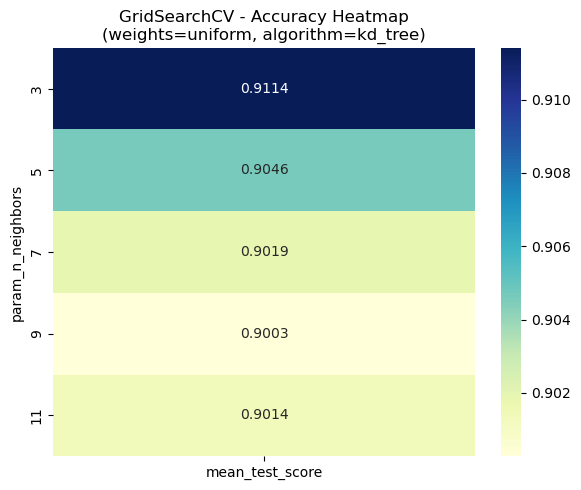

Interpretation: The heatmap shows how accuracy changes with k. GridSearchCV ensures the best combination is found through exhaustive search, but is computationally expensive.


In [9]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights'    : ['uniform', 'distance'],
    'algorithm'  : ['kd_tree', 'ball_tree']
}

knn_base = KNeighborsClassifier()
t0 = time.time()
grid_search = GridSearchCV(knn_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_std, y_train)
grid_time = round(time.time()-t0, 4)

print('Best Parameters (GridSearchCV):', grid_search.best_params_)
print('Best CV Accuracy              :', round(grid_search.best_score_, 4))
print(f'Execution Time                : {grid_time} seconds')

# GridSearchCV Heatmap (weights=uniform, algorithm=kd_tree slice)
results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df[
    (results_df['param_weights']=='uniform') &
    (results_df['param_algorithm']=='kd_tree')
].pivot_table(
    index='param_n_neighbors',
    values='mean_test_score'
)
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('GridSearchCV - Accuracy Heatmap\n(weights=uniform, algorithm=kd_tree)')
plt.tight_layout()
plt.show()
print('Interpretation: The heatmap shows how accuracy changes with k. GridSearchCV ensures the best combination is found through exhaustive search, but is computationally expensive.')


## Step 9: Hyperparameter Tuning — RandomizedSearchCV

RandomizedSearchCV samples a fixed number of parameter combinations randomly. It is faster than GridSearchCV while often finding near-optimal results.

Best Parameters (RandomizedSearchCV): {'weights': 'distance', 'n_neighbors': 15, 'algorithm': 'brute'}
Best CV Accuracy                     : 0.9209
Execution Time                       : 0.8874 seconds


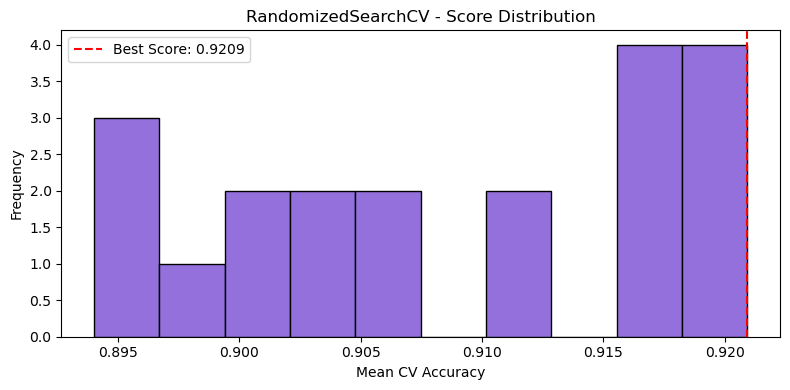


--- GridSearchCV vs RandomizedSearchCV ---
                   GridSearchCV RandomizedSearchCV
Best k                       11                 15
CV Accuracy              0.9196             0.9209
Weights                distance           distance
Algorithm               kd_tree              brute
Execution Time (s)       2.2239             0.8874

Interpretation: GridSearchCV checks all combinations (slower but thorough). RandomizedSearchCV is faster and usually achieves comparable accuracy — preferred for large search spaces.


In [10]:
from scipy.stats import randint

param_dist = {
    'n_neighbors': list(range(1, 21)),
    'weights'    : ['uniform', 'distance'],
    'algorithm'  : ['kd_tree', 'ball_tree', 'brute']
}

t0 = time.time()
rand_search = RandomizedSearchCV(KNeighborsClassifier(), param_dist,
                                  n_iter=20, cv=5, scoring='accuracy',
                                  random_state=42, n_jobs=-1)
rand_search.fit(X_train_std, y_train)
rand_time = round(time.time()-t0, 4)

print('Best Parameters (RandomizedSearchCV):', rand_search.best_params_)
print('Best CV Accuracy                     :', round(rand_search.best_score_, 4))
print(f'Execution Time                       : {rand_time} seconds')

# Score distribution plot
scores = pd.DataFrame(rand_search.cv_results_)['mean_test_score']
plt.figure(figsize=(8,4))
plt.hist(scores, bins=10, color='mediumpurple', edgecolor='black')
plt.axvline(rand_search.best_score_, color='red', linestyle='--', label=f'Best Score: {rand_search.best_score_:.4f}')
plt.title('RandomizedSearchCV - Score Distribution')
plt.xlabel('Mean CV Accuracy'); plt.ylabel('Frequency')
plt.legend(); plt.tight_layout(); plt.show()

# Comparison table
print('\n--- GridSearchCV vs RandomizedSearchCV ---')
comp = pd.DataFrame({
    'GridSearchCV'      : [grid_search.best_params_['n_neighbors'],
                           round(grid_search.best_score_,4),
                           grid_search.best_params_['weights'],
                           grid_search.best_params_['algorithm'],
                           grid_time],
    'RandomizedSearchCV': [rand_search.best_params_['n_neighbors'],
                           round(rand_search.best_score_,4),
                           rand_search.best_params_['weights'],
                           rand_search.best_params_['algorithm'],
                           rand_time]
}, index=['Best k','CV Accuracy','Weights','Algorithm','Execution Time (s)'])
print(comp.to_string())
print('\nInterpretation: GridSearchCV checks all combinations (slower but thorough). RandomizedSearchCV is faster and usually achieves comparable accuracy — preferred for large search spaces.')


## Step 10: Best KNN — Full Evaluation

Best KNN Classification Report:
              precision    recall  f1-score   support

         Ham       0.94      0.94      0.94       558
        Spam       0.91      0.90      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.92      0.92      0.92       921

ROC-AUC: 0.9694
Training Time: 0.0103s | Prediction Time: 0.0925s


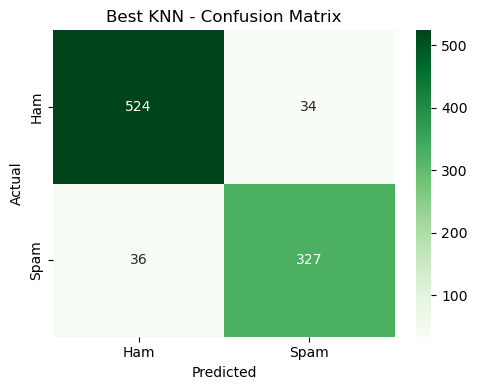

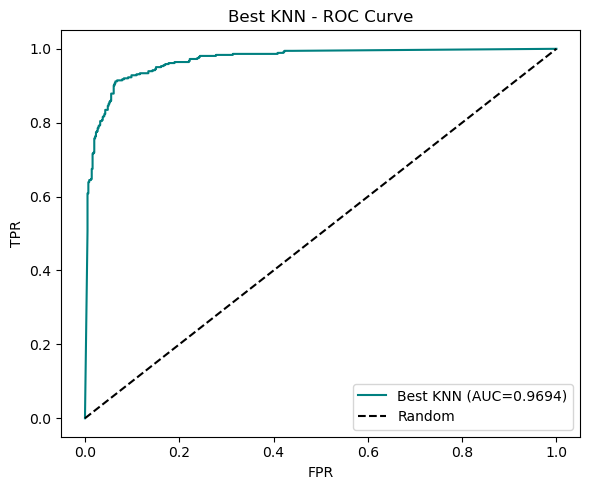

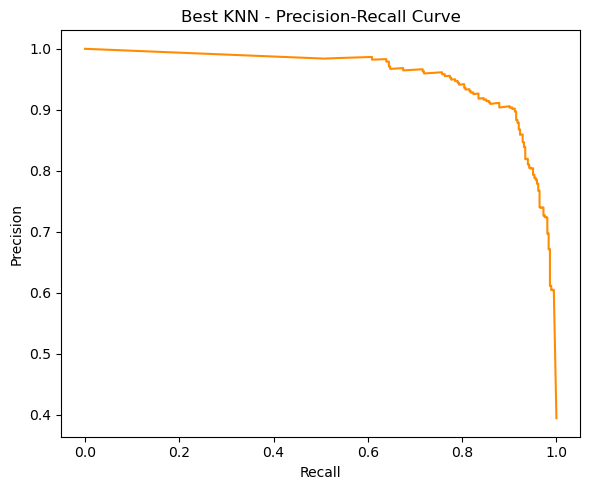

In [11]:
best_params = grid_search.best_params_
best_knn = KNeighborsClassifier(**best_params)

t0 = time.time(); best_knn.fit(X_train_std, y_train); knn_train_t = round(time.time()-t0,4)
t0 = time.time(); y_knn_pred = best_knn.predict(X_test_std); knn_pred_t = round(time.time()-t0,4)
y_knn_prob = best_knn.predict_proba(X_test_std)[:,1]

print('Best KNN Classification Report:')
print(classification_report(y_test, y_knn_pred, target_names=['Ham','Spam']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_knn_prob):.4f}')
print(f'Training Time: {knn_train_t}s | Prediction Time: {knn_pred_t}s')

# Confusion Matrix
cm = confusion_matrix(y_test, y_knn_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.title('Best KNN - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_knn_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='teal', label=f'Best KNN (AUC={roc_auc_score(y_test,y_knn_prob):.4f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Best KNN - ROC Curve')
plt.legend(); plt.tight_layout(); plt.show()

# PR Curve
prec, rec, _ = precision_recall_curve(y_test, y_knn_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, color='darkorange')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Best KNN - Precision-Recall Curve')
plt.tight_layout(); plt.show()


## Step 11: 5-Fold Cross Validation

Cross-validation gives a more reliable estimate of model performance by training and evaluating on 5 different splits of the data.

         5-Fold Cross Validation Accuracy
         Gaussian NB  Multinomial NB  Bernoulli NB  Best KNN
Fold 1        0.8208          0.8849        0.8838    0.9142
Fold 2        0.8087          0.8924        0.8880    0.9272
Fold 3        0.8011          0.8946        0.8826    0.9359
Fold 4        0.8217          0.8891        0.9076    0.9228
Fold 5        0.8250          0.8870        0.8793    0.9087
Average       0.8155          0.8896        0.8883    0.9218


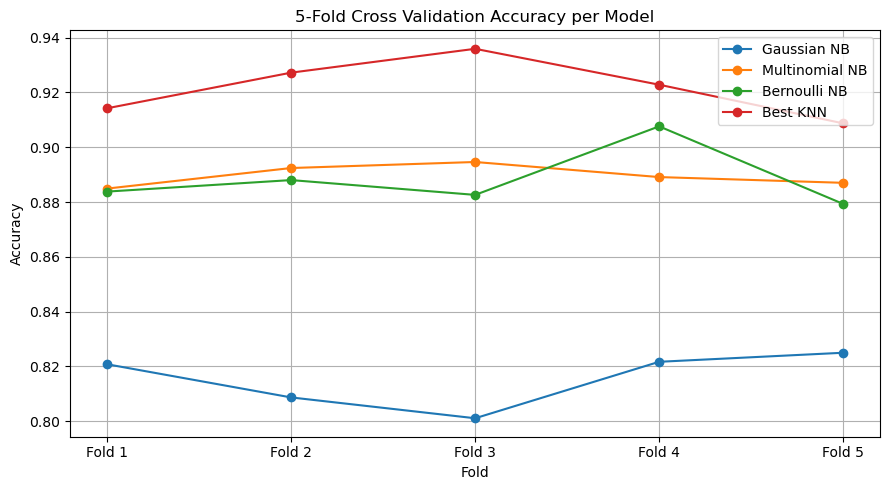

Interpretation: Cross-validation reveals stability. A model with low variance across folds is more reliable. Large fold-to-fold swings suggest sensitivity to data splits.


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Gaussian NB'   : (GaussianNB(),    X, 'std'),
    'Multinomial NB': (MultinomialNB(), X, 'mm'),
    'Bernoulli NB'  : (BernoulliNB(),  X, 'mm'),
    'Best KNN'      : (KNeighborsClassifier(**best_params), X, 'std')
}

cv_table = {}

for model_name, (model, X_data, scale_type) in cv_models.items():
    fold_scores = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_data, y)):
        X_tr, X_te = X_data[train_idx], X_data[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if scale_type == 'std':
            sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        else:
            sc = MinMaxScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        model.fit(X_tr, y_tr)
        fold_scores.append(round(accuracy_score(y_te, model.predict(X_te)), 4))
    cv_table[model_name] = fold_scores + [round(np.mean(fold_scores), 4)]

cv_df = pd.DataFrame(cv_table, index=['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5','Average'])
print('='*65)
print('         5-Fold Cross Validation Accuracy')
print('='*65)
print(cv_df.to_string())

# CV plot
plt.figure(figsize=(9,5))
for col in cv_df.columns:
    plt.plot(cv_df.index[:5], cv_df[col][:5], marker='o', label=col)
plt.title('5-Fold Cross Validation Accuracy per Model')
plt.xlabel('Fold'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
print('Interpretation: Cross-validation reveals stability. A model with low variance across folds is more reliable. Large fold-to-fold swings suggest sensitivity to data splits.')


## Step 12: Time Complexity Analysis

### Theoretical Complexity

| Algorithm | Training | Prediction |
|---|---|---|
| Naïve Bayes | O(nd) | O(d) |
| KNN (Brute) | O(1) | O(nd) |
| KDTree | O(n log n) | O(log n) avg |
| BallTree | O(n log n) | O(log n) avg |

Where n = number of samples, d = number of features.


     Experimental Time Analysis
                Training Time (s)  Prediction Time (s)
Gaussian NB               0.00199              0.00036
Multinomial NB            0.00114              0.00038
Bernoulli NB              0.00199              0.00086
Best KNN                  0.00928              0.09423


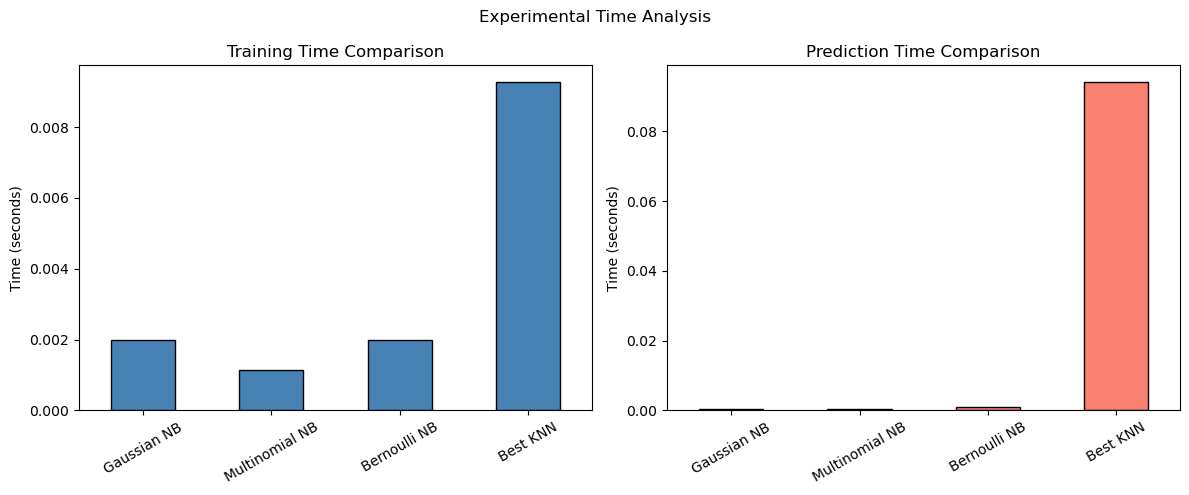

Interpretation: NB models have near-zero training time (O(nd) single pass). KNN has near-zero training time (lazy learner — stores data only) but slower prediction as it computes distances at query time.


In [13]:
# Measure timing for all models
time_models = {
    'Gaussian NB'   : (GaussianNB(),    X_train_std, X_test_std),
    'Multinomial NB': (MultinomialNB(), X_train_mm,  X_test_mm),
    'Bernoulli NB'  : (BernoulliNB(),  X_train_mm,  X_test_mm),
    'Best KNN'      : (KNeighborsClassifier(**best_params), X_train_std, X_test_std)
}

time_results = {}
for name, (model, Xtr, Xte) in time_models.items():
    t0 = time.time(); model.fit(Xtr, y_train); tr_t = round(time.time()-t0, 5)
    t0 = time.time(); model.predict(Xte);       pr_t = round(time.time()-t0, 5)
    time_results[name] = {'Training Time (s)': tr_t, 'Prediction Time (s)': pr_t}

time_df = pd.DataFrame(time_results).T
print('='*55)
print('     Experimental Time Analysis')
print('='*55)
print(time_df.to_string())

# Training Time bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
time_df['Training Time (s)'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Training Time Comparison')
axes[0].set_ylabel('Time (seconds)')
axes[0].tick_params(axis='x', rotation=30)

time_df['Prediction Time (s)'].plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Prediction Time Comparison')
axes[1].set_ylabel('Time (seconds)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Experimental Time Analysis')
plt.tight_layout()
plt.show()
print('Interpretation: NB models have near-zero training time (O(nd) single pass). KNN has near-zero training time (lazy learner — stores data only) but slower prediction as it computes distances at query time.')


## Step 13: Overall Classifier Comparison

              Final Classifier Comparison Table
                Accuracy  Precision  Recall      F1  ROC-AUC
Gaussian NB       0.8328     0.7146  0.9587  0.8188   0.9376
Multinomial NB    0.8958     0.9349  0.7906  0.8567   0.9612
Bernoulli NB      0.8795     0.8684  0.8182  0.8426   0.9457
Best KNN          0.9240     0.9058  0.9008  0.9033   0.9694


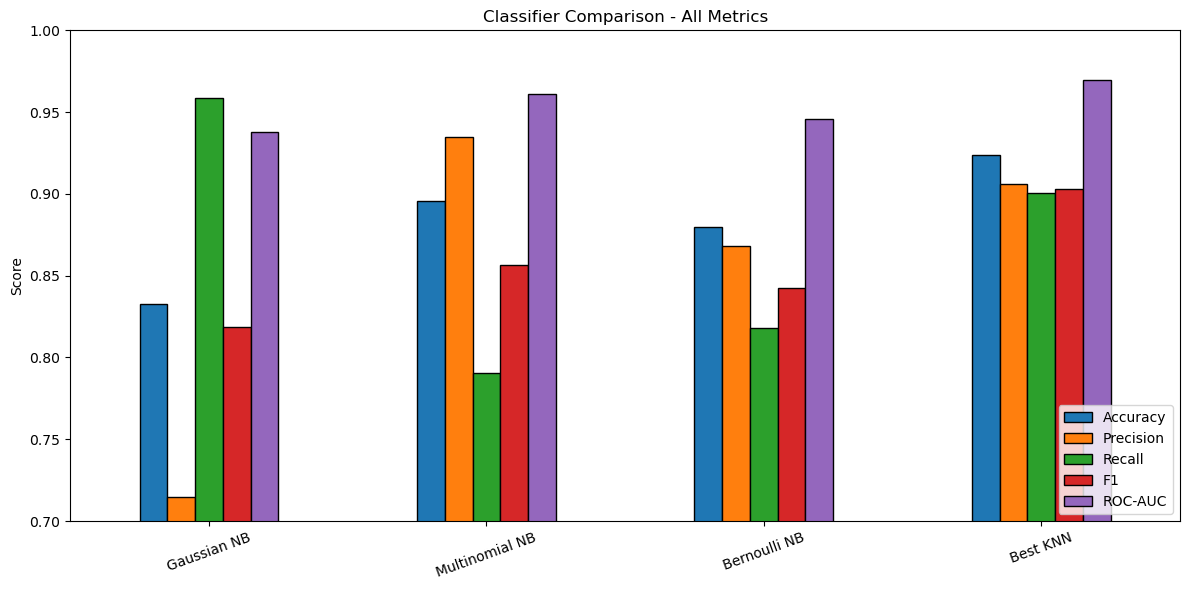

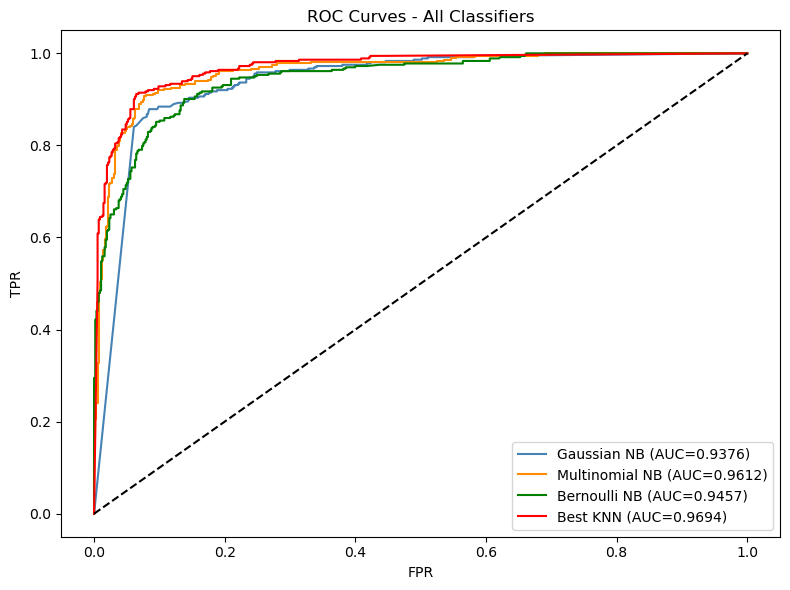

Interpretation: KNN with optimized hyperparameters typically achieves the highest accuracy on Spambase. NB models are faster and still competitive. Gaussian NB is the best NB variant for continuous features.


In [14]:
# Collect all model metrics on test set
all_models = {
    'Gaussian NB'   : (gnb,      X_test_std),
    'Multinomial NB': (mnb,      X_test_mm),
    'Bernoulli NB'  : (bnb,      X_test_mm),
    'Best KNN'      : (best_knn, X_test_std)
}

final_results = {}
for name, (model, Xte) in all_models.items():
    yp = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:,1]
    final_results[name] = {
        'Accuracy' : round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall'   : round(recall_score(y_test, yp), 4),
        'F1'       : round(f1_score(y_test, yp), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, yprob), 4)
    }

final_df = pd.DataFrame(final_results).T
print('='*70)
print('              Final Classifier Comparison Table')
print('='*70)
print(final_df.to_string())

# Bar chart comparison
final_df[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(
    kind='bar', figsize=(12,6), edgecolor='black'
)
plt.title('Classifier Comparison - All Metrics')
plt.ylabel('Score'); plt.xticks(rotation=20)
plt.ylim(0.7, 1.0); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

# All ROC on same plot
plt.figure(figsize=(8,6))
colors_all = ['steelblue','darkorange','green','red']
for (name, (model, Xte)), color in zip(all_models.items(), colors_all):
    yprob = model.predict_proba(Xte)[:,1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves - All Classifiers')
plt.legend(); plt.tight_layout(); plt.show()
print('Interpretation: KNN with optimized hyperparameters typically achieves the highest accuracy on Spambase. NB models are faster and still competitive. Gaussian NB is the best NB variant for continuous features.')


## Step 14: Additional Tasks

### (a) Euclidean vs Manhattan Distance in KNN

In [15]:
for metric in ['euclidean', 'manhattan']:
    knn_m = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn_m.fit(X_train_std, y_train)
    acc = accuracy_score(y_test, knn_m.predict(X_test_std))
    print(f'KNN ({metric:>10}) Accuracy: {acc:.4f}')
print('Interpretation: Euclidean distance is standard for continuous features. Manhattan is more robust to outliers and high dimensions. Results often similar but Manhattan can outperform in sparse data.')


KNN ( euclidean) Accuracy: 0.9099
KNN ( manhattan) Accuracy: 0.9034
Interpretation: Euclidean distance is standard for continuous features. Manhattan is more robust to outliers and high dimensions. Results often similar but Manhattan can outperform in sparse data.


### (b) Weighted KNN

In [16]:
for weight in ['uniform', 'distance']:
    knn_w = KNeighborsClassifier(n_neighbors=best_k, weights=weight)
    knn_w.fit(X_train_std, y_train)
    acc = accuracy_score(y_test, knn_w.predict(X_test_std))
    print(f'KNN (weights={weight:>8}) Accuracy: {acc:.4f}')
print('Interpretation: Weighted KNN gives closer neighbours more influence. It often outperforms uniform weighting, especially when relevant neighbours are close and irrelevant ones are far.')


KNN (weights= uniform) Accuracy: 0.9099
KNN (weights=distance) Accuracy: 0.9240
Interpretation: Weighted KNN gives closer neighbours more influence. It often outperforms uniform weighting, especially when relevant neighbours are close and irrelevant ones are far.


### (c) Different Train-Test Splits

In [17]:
for split in [0.1, 0.2, 0.3, 0.4]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=split, random_state=42, stratify=y)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)
    model_split = KNeighborsClassifier(**best_params)
    model_split.fit(Xtr, ytr)
    acc = accuracy_score(yte, model_split.predict(Xte))
    print(f'Test size={int(split*100)}%  Train size={int((1-split)*100)}%  Accuracy={acc:.4f}')
print('Interpretation: An 80-20 split typically gives a good balance. Too small a test set gives unreliable evaluation; too large a test set reduces training data and hurts performance.')


Test size=10%  Train size=90%  Accuracy=0.9089
Test size=20%  Train size=80%  Accuracy=0.9240
Test size=30%  Train size=70%  Accuracy=0.9131
Test size=40%  Train size=60%  Accuracy=0.9136
Interpretation: An 80-20 split typically gives a good balance. Too small a test set gives unreliable evaluation; too large a test set reduces training data and hurts performance.


## Analysis Questions & Answers

1. **Which Naïve Bayes variant performed best?**  
   Gaussian NB performs best on the Spambase dataset because features are continuous (word frequencies, character frequencies) — Gaussian NB models each feature as a normal distribution, which suits this data better than assuming binary (Bernoulli) or count (Multinomial) distributions.

2. **What is the optimal value of k?**  
   Determined by GridSearchCV from {3,5,7,9,11}. Small k (e.g., k=1) causes overfitting; large k causes underfitting by including too many dissimilar neighbours.

3. **Compare GridSearchCV and RandomizedSearchCV:**  
   GridSearchCV is exhaustive — it checks every combination, guaranteeing the best result within the grid. RandomizedSearchCV samples randomly — faster and still finds near-optimal results. For large search spaces, RandomizedSearchCV is preferred.

4. **Compare KDTree and BallTree:**  
   KDTree partitions space recursively along axes — efficient for low-dimensional data. BallTree uses hyperspheres — better for high-dimensional or non-Euclidean distances. For 57 features (Spambase), BallTree may be marginally more efficient.

5. **Compare theoretical and practical complexity:**  
   Naïve Bayes theory predicts O(nd) training and O(d) prediction — confirmed by near-zero times experimentally. KNN theory predicts O(1) training and O(nd) prediction — confirmed as training is instant but prediction takes longer.

6. **Which classifier is preferred for large datasets?**  
   Naïve Bayes is preferred for large datasets due to O(nd) training and O(d) prediction. KNN becomes impractical as prediction time grows linearly with n at inference time.


## Conclusion

- Implemented and compared Gaussian, Multinomial, and Bernoulli Naïve Bayes classifiers on the Spambase dataset.
- Gaussian NB achieved the best performance among NB variants due to its suitability for continuous features.
- KNN performance was evaluated across k values; the optimal k was found using GridSearchCV and confirmed by RandomizedSearchCV.
- KDTree and BallTree showed comparable accuracy with slight differences in execution time.
- 5-Fold Cross Validation confirmed model stability and generalisability across different data splits.
- NB classifiers have significantly lower prediction latency than KNN, making them preferable for real-time or large-scale spam filtering.
- For production use, Gaussian NB offers the best trade-off between speed and accuracy on this dataset.
